In [1]:
import igraph as ig
import networkx as nx
import csv
import pandas as pd
import dask.dataframe as dd 
import matplotlib.pyplot as plt


/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [2]:
# App Name
# app_name = "montage-pegasus-2mass-2deg-4node" #cosmoflow cm1
# app_name = "1000_genome_pegasus_node_16"
# app_name = "cm1"
app_name = "deepspeed-dlio-step100"
# app_name = "deepspeed-dlio-scr-step100"
# app_name = "bert"
# app_name = "unet3d"
# app_name = "resnet50"
cp_dir = "/p/lustre3/pandey2/logs/Results_Checkpoint/dataflow/"+app_name+"/"

In [3]:
fhash_dir = "/p/lustre3/pandey2/logs/Results_Checkpoint/fhash/"+app_name+"/*.parquet"
fhash = dd.read_parquet(fhash_dir)
def getFilename(hash_value, fhash_df):
    result = fhash_df.query(f"hash == '{hash_value}'").compute()
    return result['name'].values

# Lvl3 

In [4]:

# create nx graph from original Networks

# Read the CSV file
df1 = pd.read_csv(cp_dir+"l3.csv", header=None, delimiter=" ", names=['src', 'dest'])
G3 = nx.DiGraph()
edge_list = list(zip(df1['src'], df1['dest']))
G3.add_edges_from(edge_list)


In [5]:
df1.head()

,src,dest
0,corona202,1.7827825848209795e+19
1,corona202,1.723427120640777e+18
2,corona202,1.4433171253546033e+19
3,corona202,9.061657290076685e+18
4,corona202,1.8128740601322631e+19


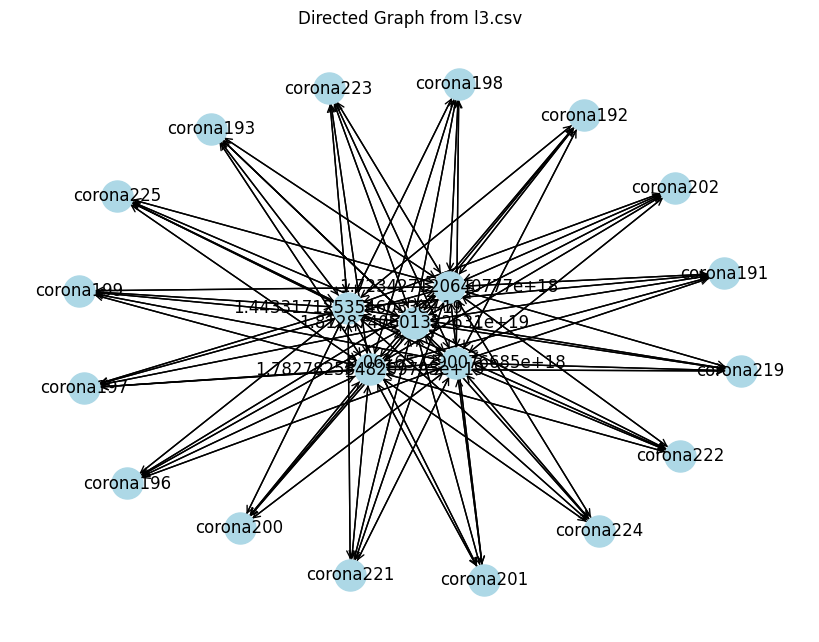

In [6]:
# Draw the graph with labels and arrows
plt.figure(figsize=(8, 6))  # Set figure size
pos = nx.spring_layout(G3)  # Layout for node positions

nx.draw(G3, pos, with_labels=True, node_size=500, node_color='lightblue', 
        arrows=True, arrowstyle='->', arrowsize=12)

plt.title("Directed Graph from l3.csv")
plt.axis('off')  # Hide axis
plt.show()

In [7]:
df1.src.unique()

array(['corona202', '1.7827825848209795e+19', 'corona201', 'corona196',
       'corona222', 'corona221', 'corona197', 'corona198', 'corona199',
       'corona223', 'corona192', 'corona225', 'corona191', 'corona219',
       'corona200', 'corona224', 'corona193', '1.723427120640777e+18',
       '1.4433171253546033e+19', '9.061657290076685e+18',
       '1.8128740601322631e+19'], dtype=object)

In [8]:
print(getFilename('1.7827825848209795e+19',fhash)[0])
print(getFilename('1.723427120640777e+18',fhash)[0])
print(getFilename('1.4433171253546033e+19',fhash)[0])
print(getFilename('9.061657290076685e+18',fhash)[0])
print(getFilename('1.8128740601322631e+19',fhash)[0])

/usr/WS2/haridev/iopp/apps/dlio/hydra_log/megatron_deepspeed/2024-10-11-11-00-59/.hydra/config.yaml
/usr/WS2/haridev/iopp/apps/dlio/hydra_log/megatron_deepspeed/2024-10-11-11-00-59/.hydra/hydra.yaml
/usr/WS2/haridev/iopp/apps/dlio/hydra_log/megatron_deepspeed/2024-10-11-11-00-59/.hydra/overrides.yaml
/usr/workspace/haridev/iopp/apps/dlio/output/megatron_deepspeed-2-step100-scr0-opt0_16_8/dlio.log
/dev/infiniband/rdma_cm


In [9]:
bet_centrality = nx.betweenness_centrality(G3, normalized=True, weight=None)

# Display the centrality values
for node, centrality in bet_centrality.items():
    print(f"Node: {node}, Betweenness Centrality: {centrality:.6f}")

Node: corona202, Betweenness Centrality: 0.003289
Node: 1.7827825848209795e+19, Betweenness Centrality: 0.126316
Node: 1.723427120640777e+18, Betweenness Centrality: 0.126316
Node: 1.4433171253546033e+19, Betweenness Centrality: 0.126316
Node: 9.061657290076685e+18, Betweenness Centrality: 0.126316
Node: 1.8128740601322631e+19, Betweenness Centrality: 0.126316
Node: corona201, Betweenness Centrality: 0.003289
Node: corona196, Betweenness Centrality: 0.003289
Node: corona222, Betweenness Centrality: 0.003289
Node: corona221, Betweenness Centrality: 0.003289
Node: corona197, Betweenness Centrality: 0.003289
Node: corona198, Betweenness Centrality: 0.003289
Node: corona199, Betweenness Centrality: 0.003289
Node: corona223, Betweenness Centrality: 0.003289
Node: corona192, Betweenness Centrality: 0.003289
Node: corona225, Betweenness Centrality: 0.003289
Node: corona191, Betweenness Centrality: 0.003289
Node: corona219, Betweenness Centrality: 0.003289
Node: corona200, Betweenness Centrali

# Lvl1

In [10]:

# read parquet file groupby hostname and do analysis in each group
cp_dir+"lvl1/*.parquet"
df2 = dd.read_parquet(cp_dir+"lvl1/*.parquet")
df_singlehost = df2.reset_index().query("hostname == 'corona198'")
df_singlehost['pid'] = df_singlehost['pid'].apply(lambda x:f'p_{x}')
df_singlehost.groupby(['pid','fhash']).count().compute()


/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/core.py:4448: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map or apply function that you are using.
  Before: .apply(func)
  After:  .apply(func, meta=('pid', 'object'))

  warnings.warn(meta_warning(meta))


index  hostname  ts
pid       fhash                                      
p_1447578 1.0013713109605163e+19      1         1   1
          1.0016633955265067e+19      1         1   1
          1.0016904716499659e+19      1         1   1
          1.0042729642576386e+19      1         1   1
          1.004276247343186e+19       1         1   1
...                                 ...       ...  ..
p_1447585 9.97870246402733e+18        1         1   1
          9.98525641926616e+18        1         1   1
          9.986626790833402e+18       1         1   1
          9.997903485690952e+18       1         1   1
          9.997942851640295e+18       1         1   1

[26048 rows x 3 columns]

/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/core.py:8153: UserWarning: Insufficient elements for `head`. 5 elements requested, only 0 elements available. Try passing larger `npartitions` to `head`.
  warnings.warn(


In [11]:
print(getFilename('1.0016633955265067e+19',fhash)[0])
print(getFilename('1.0016633955265067e+19',fhash)[0])
print(getFilename('1.0016904716499659e+19',fhash)[0])
print(getFilename('1.0042729642576386e+19',fhash)[0])
print("****")
print(getFilename('9.97870246402733e+18',fhash)[0])
print(getFilename('9.98525641926616e+18',fhash)[0])
print(getFilename('9.986626790833402e+18',fhash)[0])
print(getFilename('9.997903485690952e+18',fhash)[0])

/dev/shm/torch_1450778_3747749818_135
/dev/shm/torch_1450778_3747749818_135
/dev/shm/torch_1450238_1552531731_414
/dev/shm/torch_1448104_2654131970_422
****
/dev/shm/torch_1449174_2045195302_350
/dev/shm/torch_1448672_2752963275_184
/dev/shm/torch_1448672_2056226545_474
/dev/shm/torch_1448167_278212378_133


In [60]:
df2.fhash.unique().compute()

0          1.000160077285259e+19
1         1.0002122491058502e+19
2         1.0002627534595666e+19
3          1.000313961871544e+19
4          1.000325340882533e+19
                   ...          
414210     9.995606683497929e+18
414211      9.99716537952927e+18
414212      9.99762866621407e+18
414213     9.998501463055022e+18
414214        9747829906740392.0
Name: fhash, Length: 414215, dtype: string

# Lvl2

In [12]:
# Step 2: Level 1 and 2 # per node basis
# read parquet file groupby hostname and do analysis in each group
df3 = dd.read_parquet(cp_dir+"lvl2/*.parquet")
df_singlehost = df3.reset_index().query("hostname == 'corona198'")
df_singlehost.head()
df_singlehost['pid_prod'] = df_singlehost['pid_prod'].apply(lambda x:f'p_{x}')
df_singlehost['pid_cons'] = df_singlehost['pid_cons'].apply(lambda x:f'p_{x}')
df_singlehost.compute()

/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/core.py:4448: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map or apply function that you are using.
  Before: .apply(func)
  After:  .apply(func, meta=('pid_prod', 'object'))

  warnings.warn(meta_warning(meta))
/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/core.py:4448: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map or apply function that you are using.
  Before: .apply(func)
  After:  .apply(func, 

,index,hostname,level_1,pid_prod,fhash,pid_cons,ts_prod,ts_cons
0,0,corona198,6863,p_1447578,1.4433171253546033e+19,p_1447579,27724980,27717244
1,1,corona198,6864,p_1447578,1.4433171253546033e+19,p_1447580,27724980,27725687
2,2,corona198,6865,p_1447578,1.4433171253546033e+19,p_1447581,27724980,27722723
3,3,corona198,6866,p_1447578,1.4433171253546033e+19,p_1447582,27724980,27721175
4,4,corona198,6867,p_1447578,1.4433171253546033e+19,p_1447583,27724980,27715052
...,...,...,...,...,...,...,...,...
275,275,corona198,24808,p_1447585,9.061657290076685e+18,p_1447580,34968808,34968811
276,276,corona198,24809,p_1447585,9.061657290076685e+18,p_1447581,34968808,34968813
277,277,corona198,24810,p_1447585,9.061657290076685e+18,p_1447582,34968808,34968560
278,278,corona198,24811,p_1447585,9.061657290076685e+18,p_1447583,34968808,34968477


In [13]:
G = nx.DiGraph()
for _, row in df_singlehost.iterrows():
    G.add_edge(row['pid_prod'], row['fhash'])
    G.add_edge(row['fhash'], row['pid_cons'])

In [14]:
f_nodes = [node for node in G.nodes if isinstance(node, str) and not node.startswith('p')]
f_nodes

['1.4433171253546033e+19',
 '1.723427120640777e+18',
 '1.7827825848209795e+19',
 '1.8128740601322631e+19',
 '9.061657290076685e+18']

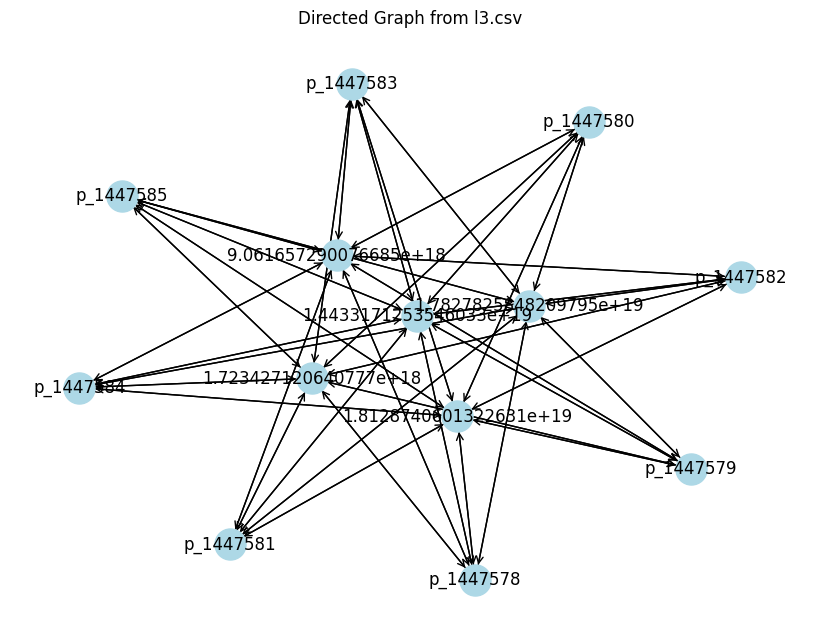

In [15]:
# Draw the graph with labels and arrows
plt.figure(figsize=(8, 6))  # Set figure size
pos = nx.spring_layout(G)  # Layout for node positions

nx.draw(G, pos, with_labels=True, node_size=500, node_color='lightblue', 
        arrows=True, arrowstyle='->', arrowsize=12)

plt.title("Directed Graph from l3.csv")
plt.axis('off')  # Hide axis
plt.show()

In [16]:
print(getFilename('1.4433171253546033e+19',fhash)[0])
print(getFilename('1.723427120640777e+18',fhash)[0])
print(getFilename('1.7827825848209795e+19',fhash)[0])
print(getFilename('1.8128740601322631e+19',fhash)[0])
print(getFilename('9.061657290076685e+18',fhash)[0])

/usr/WS2/haridev/iopp/apps/dlio/hydra_log/megatron_deepspeed/2024-10-11-11-00-59/.hydra/overrides.yaml
/usr/WS2/haridev/iopp/apps/dlio/hydra_log/megatron_deepspeed/2024-10-11-11-00-59/.hydra/hydra.yaml
/usr/WS2/haridev/iopp/apps/dlio/hydra_log/megatron_deepspeed/2024-10-11-11-00-59/.hydra/config.yaml
/dev/infiniband/rdma_cm
/usr/workspace/haridev/iopp/apps/dlio/output/megatron_deepspeed-2-step100-scr0-opt0_16_8/dlio.log


In [17]:
bet_centrality = nx.betweenness_centrality(G, normalized=True, weight=None)

# Display the centrality values
for node, centrality in bet_centrality.items():
    print(f"Node: {node}, Betweenness Centrality: {centrality:.6f}")

Node: p_1447578, Betweenness Centrality: 0.018939
Node: 1.4433171253546033e+19, Betweenness Centrality: 0.084848
Node: p_1447579, Betweenness Centrality: 0.018939
Node: p_1447580, Betweenness Centrality: 0.018939
Node: p_1447581, Betweenness Centrality: 0.018939
Node: p_1447582, Betweenness Centrality: 0.018939
Node: p_1447583, Betweenness Centrality: 0.018939
Node: p_1447584, Betweenness Centrality: 0.018939
Node: p_1447585, Betweenness Centrality: 0.018939
Node: 1.723427120640777e+18, Betweenness Centrality: 0.084848
Node: 1.7827825848209795e+19, Betweenness Centrality: 0.084848
Node: 1.8128740601322631e+19, Betweenness Centrality: 0.084848
Node: 9.061657290076685e+18, Betweenness Centrality: 0.084848
